In [1]:
import os
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> project root
os.chdir(ROOT)


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)

ROOT      = Path().resolve()
DATA_PATH = ROOT / "data" / "processed"
RAW_PATH  = ROOT / "data" / "raw" / "finanças"

# ── Configurações de campanha ─────────────────────────────────────────────────
JANELAS = {
    2014: (pd.Timestamp("2014-07-06"), pd.Timestamp("2014-10-05")),
    2018: (pd.Timestamp("2018-08-16"), pd.Timestamp("2018-10-07")),
    2022: (pd.Timestamp("2022-08-16"), pd.Timestamp("2022-10-02")),
}
DURACAO = {ano: (fim - inicio).days for ano, (inicio, fim) in JANELAS.items()}
# 2014: 91 dias (pré-FEFC) | 2018: 52 dias | 2022: 47 dias

# ── Dataset para figuras de AME (modelo fracionário) ─────────────────────────
df_output_modelo = pd.read_parquet(DATA_PATH / "df_ame_baseline.parquet")

# ── Dados transacionais — para análise de fluxo cumulativo ───────────────────
ARQUIVOS_RECEITAS = {
    2014: RAW_PATH / "receitas_candidatos_2014_brasil.txt",
    2018: RAW_PATH / "receitas_candidatos_2018_BRASIL.csv",
    2022: RAW_PATH / "receitas_candidatos_2022_BRASIL.csv",
}

# Arquivo 2014 tem nomes de colunas diferentes dos demais anos.
_RENAME_2014 = {
    "cargo":            "ds_cargo",
    "fonte recurso":    "ds_fonte_receita",
    "valor receita":    "vr_receita",
    "data da receita":  "dt_receita",   # formato "DD/MM/YYYYHH:MM:SS" sem espaço
    "uf":               "sg_uf",
    "sigla  partido":   "sg_partido",   # duas espaços no original
    "numero candidato": "nr_candidato",
    # "tipo receita" não renomeado — usado no mapeamento de fonte_tipo abaixo
}

# Fontes que representam repasse direto do partido (coordenação de campanha)
FONTES_PARTIDO = {"FP", "PJ_ROTEADO", "FEFC"}


def ler_tab_receitas(path_arquivo):
    return pd.read_csv(path_arquivo, sep=";", encoding="latin-1", low_memory=False)


def tratar_df_receita(df, ano):
    """Carrega TODOS os tipos de receita para Dep. Federal.

    fonte_tipo classifica a origem do recurso:
      2014: FP | PJ_ROTEADO | PJ_DIRETO | PF | PROPRIO | OUTROS_CAND | OUTROS
      2018/2022: FEFC | FP | PF | PROPRIO | OUTROS_CAND | FINANCIAMENTO_COLETIVO | OUTROS

    Para análises de coordenação partidária, filtrar pelo set FONTES_PARTIDO.
    """
    df.columns = df.columns.str.lower()

    rename = {k: v for k, v in _RENAME_2014.items() if k in df.columns}
    if rename:
        df = df.rename(columns=rename)

    df["ds_cargo"]         = df["ds_cargo"].str.strip().str.title()
    df["ds_fonte_receita"] = df["ds_fonte_receita"].str.upper()

    df = df.loc[df["ds_cargo"] == "Deputado Federal"].copy()

    if ano == 2014:
        tipo = df["tipo receita"].str.strip()
        df["fonte_tipo"] = np.select(
            [
                (tipo == "Recursos de partido político") & (df["ds_fonte_receita"] == "FUNDO PARTIDARIO"),
                (tipo == "Recursos de partido político"),
                tipo == "Recursos de pessoas jurídicas",
                tipo == "Recursos de pessoas físicas",
                tipo == "Recursos próprios",
                tipo == "Recursos de outros candidatos/comitês",
            ],
            ["FP", "PJ_ROTEADO", "PJ_DIRETO", "PF", "PROPRIO", "OUTROS_CAND"],
            default="OUTROS",
        )
        df["dt_receita"] = pd.to_datetime(df["dt_receita"].str[:10], format="%d/%m/%Y")
    else:
        # 2018/2022: ds_fonte_receita distingue FEFC/FP; ds_origem_receita distingue PF/próprios/etc.
        origem = df["ds_origem_receita"].str.strip()
        df["fonte_tipo"] = np.select(
            [
                df["ds_fonte_receita"] == "FUNDO ESPECIAL",
                df["ds_fonte_receita"] == "FUNDO PARTIDARIO",
                origem == "Recursos de pessoas físicas",
                origem == "Recursos próprios",
                origem == "Recursos de outros candidatos",
                origem == "Recursos de Financiamento Coletivo",
            ],
            ["FEFC", "FP", "PF", "PROPRIO", "OUTROS_CAND", "FINANCIAMENTO_COLETIVO"],
            default="OUTROS",
        )
        df["dt_receita"] = pd.to_datetime(df["dt_receita"], dayfirst=True)

    df["vr_receita"] = df["vr_receita"].astype(str).str.replace(",", ".").astype(float)
    df["ano_eleicao"] = ano

    inicio, fim = JANELAS[ano]
    df = df.loc[(df["dt_receita"] >= inicio) & (df["dt_receita"] <= fim)].copy()

    df = df.groupby(
        ["ano_eleicao", "dt_receita", "sg_uf", "sg_partido", "nr_candidato", "fonte_tipo"],
        as_index=False,
    )["vr_receita"].sum()
    return df


def main():
    """Dados transacionais de TODOS os tipos de receita para Dep. Federal, 2014/2018/2022.

    Use FONTES_PARTIDO para filtrar apenas repasses do partido (FP/PJ_ROTEADO/FEFC).
    """
    partes = [tratar_df_receita(ler_tab_receitas(p), ano)
              for ano, p in ARQUIVOS_RECEITAS.items()]
    df = pd.concat(partes, ignore_index=True)
    df["nr_candidato"] = df["nr_candidato"].astype(str)
    return df


In [3]:
# ── Dataset analítico principal: rrd_df_novo (2014 + 2018 + 2022) ───────────
rrd = pd.read_parquet(DATA_PATH / "rrd_df_novo.parquet")
rrd["nr_candidato"] = rrd["nr_candidato"].astype(str)

# Aliases de compatibilidade para células subsequentes
rrd["dias_primeira_receita"]  = rrd["dias_desde_inicio"]
rrd["receita_total_candidato"] = rrd["vr_receita_recursos_partidos"].fillna(0)
rrd["dt_primeira_receita"]    = rrd["dt_receita"]

# Métricas granulares não disponíveis no rrd agregado (mantidas como NaN)
for col in ["gap_primeira_maior_receita", "share_primeira_receita",
            "maior_receita", "dias_maior_receita"]:
    rrd[col] = np.nan

rrd_df_merge = rrd.copy()

print("Candidatos por ano:")
print(rrd_df_merge.groupby("ano_eleicao").size().rename("n_candidatos").to_frame())
print(f"\nColunas ({len(rrd_df_merge.columns)}): {list(rrd_df_merge.columns)}")


Candidatos por ano:
             n_candidatos
ano_eleicao              
2014                 6178
2018                 7630
2022                 9675

Colunas (35): ['ano_eleicao', 'sg_uf', 'sg_partido', 'nr_candidato', 'nm_candidato', 'ds_sit_tot_turno', 'qt_votos_nominais', 'nr_cpf_candidato', 'n_eleicoes_prefeito', 'n_eleicoes_vereador', 'n_eleicoes_deputado_estadual', 'n_eleicoes_deputado_federal', 'n_eleicoes_governador', 'n_eleicoes_senador', 'vr_receita_outros', 'vr_receita_recursos_partidos', 'vr_receita_fefc', 'vr_receita_fp', 'qe', 'qt_vaga', 'dt_receita', 'fonte_primeiro_repasse', 'dias_desde_inicio', 'prop_votos_nominais_lag', 'alcancou_10pct_qe_hist', 'alcancou_10pct_qe_hist_nom', '10pct_qe_eleicao_atual', 'eleito', 'dias_primeira_receita', 'receita_total_candidato', 'dt_primeira_receita', 'gap_primeira_maior_receita', 'share_primeira_receita', 'maior_receita', 'dias_maior_receita']


In [4]:
px.histogram(
    rrd_df_merge,
    x="dias_primeira_receita",
    color="ano_eleicao",
    barmode="overlay",
    title="Quantos dias de campanha se passaram até o primeiro repasse?"
)

In [5]:
px.histogram(
    rrd_df_merge,
    x="gap_primeira_maior_receita",
    color="ano_eleicao",
    barmode="overlay",
    title="Quantos dias se passaram entre o primeiro repasse e o maior repasse?"
)

In [6]:
rrd_df_merge['gap_primeira_maior_receita'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: gap_primeira_maior_receita, dtype: float64

In [7]:
px.histogram(
    rrd_df_merge,
    x="share_primeira_receita",
    # color="ano_eleicao",
    barmode="overlay",
    title="Qual o share da primeira receita em relação ao total arrecadado?",
    nbins=10
)

In [8]:
rrd_df_merge['share_primeira_receita'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: share_primeira_receita, dtype: float64

In [9]:
rrd_df_merge['eleito'] = np.where(
    rrd_df_merge['ds_sit_tot_turno'].isin(['ELEITO POR QP', 'ELEITO POR MÉDIA']),
    1,
    0
)

In [10]:
rrd_df_merge.groupby("eleito")['dias_maior_receita'].describe()

,count,mean,std,min,25%,50%,75%,max
eleito,,,,,,,,
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
rrd_df_merge['n_eleicoes_deputado_federal'] = rrd_df_merge['n_eleicoes_deputado_federal'].fillna(0).astype(int)
px.box(
    rrd_df_merge.dropna(subset=['dias_maior_receita']),
    x='n_eleicoes_deputado_federal',
    y='dias_maior_receita',
    height=600,
)

In [12]:
px.box(
    rrd_df_merge.dropna(subset=["dias_primeira_receita"]),
    x="n_eleicoes_deputado_federal",
    y="dias_primeira_receita",
)

In [13]:
df_output_modelo_print = df_output_modelo.loc[
    ~df_output_modelo["variavel"].str.startswith("C")
].copy()

df_output_modelo_print["variavel"] = (
    df_output_modelo_print["variavel"]
    .str.replace("n_eleicoes_deputado_estadual", "Nº Eleições Deputado Estadual")
    .str.replace("n_eleicoes_deputado_federal", "Nº Eleições Deputado Federal")
    .str.replace("n_eleicoes_senador", "Nº Eleições Senador")
    .str.replace("n_eleicoes_governador", "Nº Eleições Governador")
    .str.replace("n_eleicoes_vereador", "Nº Eleições Vereador")
    .str.replace("n_eleicoes_prefeito", "Nº Eleições Prefeito")
    .str.replace("np.log(qt_vaga)", "Ln Magnitude do distrito")
    .str.replace(
        "prop_votos_nominais_lag", "Proporção de votos nominais intralista t-1"
    )
)


fig_modelo = px.scatter(
    df_output_modelo_print.sort_values("variavel", ascending=False),
    y="variavel",
    x="dy/dx",
    error_x="Std. Err.",
    labels={"dy/dx": "AME", "variavel": "Variável"},
    template="plotly_white",
    color="ano",
    width=800,
    symbol="ano",
    color_discrete_sequence=["black", "grey"],
    text="dy/dx",
)
fig_modelo.add_vline(x=0, line_dash="dash", line_color="grey")
fig_modelo.update_layout(
    legend=dict(
        orientation="h",        # horizontal
        yanchor="bottom",
        y=1.02,                # posição acima do plot; ajuste (p.ex. 1.08) para mais distância
        xanchor="center",
        x=0.5,
        title_text="Eleições"  # altera o título
    ),
    font=dict(size=14),
    margin=dict(l=140, r=40, t=40, b=40),
    width=900,
    height=500,
    autosize=False,
)
fig_modelo.update_yaxes(tickfont=dict(size=12))
fig_modelo.update_xaxes(tickfont=dict(size=12))
fig_modelo.update_traces(
    texttemplate="%{text:.2f}",
    textposition="top center",
    marker=dict(size=13),
)

## Modelo de Duração: Tempo até o Primeiro Repasse

A variável dependente é o número de dias desde o início da campanha até o primeiro repasse de recursos partidários ao candidato.

- **Evento:** primeiro repasse de recursos ao candidato
- **Origem do tempo:** início oficial da campanha — 2014: 06/07 (FP, pré-FEFC) | 2018/2022: 16/08 (FEFC+FP)
- **Censura à direita:** candidatos que não receberam nenhum repasse são censurados ao final da janela (2014: 91 dias | 2018: 52 dias | 2022: 47 dias)
- **2014 como baseline pré-FEFC:** o mecanismo em 2014 é o Fundo Partidário (descentralizado); a comparação com 2018/2022 ilustra o efeito da introdução do FEFC

A censura não é aleatória — representa a decisão do partido de não transferir recursos — e será discutida como tal na tese.

Todos os preditores são observáveis **antes** da eleição: histórico eleitoral acumulado e desempenho intralista na eleição anterior. O resultado eleitoral não entra como preditor para evitar a circularidade diagnosticada por Bolognesi et al. (2020) e Guarnieri & Silva (2025).


In [14]:
# -- Candidato competitivo (ex-ante) -- pre-computa antes das secoes de KM e acumulado
n_eleicoes_cols_cs = [
    'n_eleicoes_prefeito', 'n_eleicoes_deputado_estadual',
    'n_eleicoes_deputado_federal', 'n_eleicoes_governador', 'n_eleicoes_senador',
]
rrd_df_merge['incumbente'] = rrd_df_merge[n_eleicoes_cols_cs].fillna(0).sum(axis=1) > 0
rrd_df_merge['candidato_competitivo'] = (
    rrd_df_merge['incumbente']
    | rrd_df_merge['alcancou_10pct_qe_hist'].fillna(False)
)
print('candidato_competitivo computado:', rrd_df_merge['candidato_competitivo'].value_counts().to_dict())


candidato_competitivo computado: {False: 20690, True: 2793}


In [15]:
from lifelines import CoxPHFitter, WeibullAFTFitter, KaplanMeierFitter
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

ELEITO_CATS = ['ELEITO', 'ELEITO POR MEDIA', 'MEDIA', 'ELEITO POR QP']
rrd_df_merge['eleito'] = rrd_df_merge['ds_sit_tot_turno'].isin(ELEITO_CATS).astype(int)

# Cluster id para SE clusterizados por partido × UF
rrd_df_merge["partido_uf"] = rrd_df_merge["sg_partido"] + "_" + rrd_df_merge["sg_uf"]

covs_modelo = [
    'n_eleicoes_deputado_federal',
    'n_eleicoes_deputado_estadual',
    'n_eleicoes_vereador',
    'n_eleicoes_prefeito',
    'n_eleicoes_governador',
    'n_eleicoes_senador',
    'prop_votos_nominais_lag',
    'log_qt_vaga',
    'mulher',
    'negra',
]


def preparar_survival(df, ano):
    d = df.loc[df['ano_eleicao'] == ano].copy()
    dur_max = DURACAO[ano]
    # Usa dias_desde_inicio do rrd (já calculado pelo pipeline)
    d['duration'] = d['dias_desde_inicio'].fillna(dur_max).clip(upper=dur_max)
    d['event']    = d['dias_desde_inicio'].notna().astype(int)
    for c in covs_modelo:
        if c.startswith('n_eleicoes'):
            d[c] = d[c].fillna(0).astype(float)
    d['log_qt_vaga'] = np.log(d['qt_vaga'])
    cols = ['nr_candidato', 'sg_uf', 'sg_partido', 'partido_uf',
            'duration', 'event', 'eleito'] + covs_modelo
    # dropna exclui NaN residuais em prop_votos_nominais_lag (CPF="-4", ~1 caso/ano)
    return d[cols].dropna(subset=covs_modelo + ['duration', 'event'])


survival_dfs = {ano: preparar_survival(rrd_df_merge, ano) for ano in [2014, 2018, 2022]}
df_surv_14 = survival_dfs[2014]
df_surv_18 = survival_dfs[2018]
df_surv_22 = survival_dfs[2022]

for ano, df in survival_dfs.items():
    ev   = int(df['event'].sum())
    cens = int((df['event'] == 0).sum())
    pct  = ev / len(df) * 100
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"{ano}{label} — N={len(df):,} | eventos={ev:,} ({pct:.0f}%) | censurados={cens:,}")


2014 (pré-FEFC / FP) — N=6,177 | eventos=2,298 (37%) | censurados=3,879
2018 — N=7,626 | eventos=5,336 (70%) | censurados=2,290
2022 — N=9,672 | eventos=8,566 (89%) | censurados=1,106


In [16]:
# Kaplan-Meier — competitivo vs. não-competitivo
# Layout 2×3:
#   Linha 1 → 2014 Total (todos os recursos) | 2014 Fundo Partidário | 2014 PJ→Partido
#   Linha 2 → 2018                            | 2022                   | (vazio)
#
# 2014 subdividido por tipo de recurso — evento = primeiro recebimento daquele tipo.
# 2018/2022 mantêm a definição original: primeiro repasse FEFC+FP (via rrd dias_desde_inicio).

from plotly.subplots import make_subplots

cores_km  = {"Candidato competitivo": "black",     "Candidato não-competitivo": "lightgrey"}
dashes_km = {"Candidato competitivo": "solid",      "Candidato não-competitivo": "dot"}
grupos_km = ["Candidato competitivo", "Candidato não-competitivo"]

cs_lookup = rrd_df_merge[
    ["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]
].drop_duplicates()

# ── Dados transacionais 2014 para os sub-painéis FP e PJ_ROTEADO ─────────────
_df14_raw = tratar_df_receita(ler_tab_receitas(ARQUIVOS_RECEITAS[2014]), 2014)
_df14_raw["nr_candidato"] = _df14_raw["nr_candidato"].astype(str)
_df14_raw["dias_campanha"] = (_df14_raw["dt_receita"] - JANELAS[2014][0]).dt.days

_cands_2014 = (
    cs_lookup[cs_lookup["ano_eleicao"] == 2014]
    [["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]]
    .drop_duplicates()
)

def _km_2014(fonte_tipos=None):
    src = _df14_raw if fonte_tipos is None else _df14_raw[_df14_raw["fonte_tipo"].isin(fonte_tipos)]
    first = (
        src.groupby(["sg_uf", "sg_partido", "nr_candidato"])["dias_campanha"]
        .min().reset_index().rename(columns={"dias_campanha": "dias_primeiro"})
    )
    d = _cands_2014.merge(first, on=["sg_uf", "sg_partido", "nr_candidato"], how="left")
    d["duration"]        = d["dias_primeiro"].fillna(DURACAO[2014]).clip(upper=DURACAO[2014])
    d["event"]           = d["dias_primeiro"].notna().astype(int)
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[2014] / 7)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    return d

def _km_1822(df_surv, ano):
    d = df_surv.merge(
        cs_lookup.loc[cs_lookup["ano_eleicao"] == ano,
                      ["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]],
        on=["sg_uf", "sg_partido", "nr_candidato"], how="left",
    )
    d["candidato_competitivo"] = d["candidato_competitivo"].fillna(False)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[ano] / 7)
    return d

PAINEIS_KM = [
    ("2014 — Total",               _km_2014(None)),
    ("2014 — Fundo Partidário",    _km_2014(["FP"])),
    ("2014 — PJ → Partido → Cand.", _km_2014(["PJ_ROTEADO"])),
    ("2018",                        _km_1822(df_surv_18, 2018)),
    ("2022",                        _km_1822(df_surv_22, 2022)),
]

specs_km = [
    [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    [{"type": "xy"}, {"type": "xy"}, None],
]
pos_km = {i: (1 + i // 3, (i % 3) + 1) for i in range(len(PAINEIS_KM))}

fig_km_cs = make_subplots(
    rows=2, cols=3,
    shared_yaxes=True,
    subplot_titles=[p[0] for p in PAINEIS_KM],
    specs=specs_km,
    vertical_spacing=0.18,
    horizontal_spacing=0.06,
)

for i, (titulo, d) in enumerate(PAINEIS_KM):
    row, col = pos_km[i]
    n_ev = int(d["event"].sum())
    print(f"{titulo}: N={len(d):,} | eventos={n_ev:,} ({n_ev/len(d)*100:.0f}%) | censurados={len(d)-n_ev:,}")
    for grupo in grupos_km:
        mask = d["grupo_cs"] == grupo
        kmf = KaplanMeierFitter()
        kmf.fit(d.loc[mask, "duration_semana"], event_observed=d.loc[mask, "event"], label=grupo)
        sf = kmf.survival_function_
        fig_km_cs.add_trace(
            go.Scatter(
                x=kmf.timeline, y=sf[grupo].values,
                mode="lines", name=grupo,
                showlegend=(i == 0),
                line=dict(color=cores_km[grupo], width=2.5, dash=dashes_km[grupo]),
            ),
            row=row, col=col,
        )

fig_km_cs.update_layout(
    legend=dict(title="Candidato competitivo (ex-ante)",
                orientation="h", x=0.5, xanchor="center", y=1.12, yanchor="top"),
    height=640, width=1200, template="plotly_white",
    margin=dict(t=80, b=50),
)
fig_km_cs.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_km_cs.update_yaxes(title_text="S(t)", range=[0, 1.05], col=1)

fig_km_cs.write_image("figs/cap3_survival_km_cs.png", scale=2)
fig_km_cs.show(config={"staticPlot": True})


2014 — Total: N=6,178 | eventos=5,134 (83%) | censurados=1,044
2014 — Fundo Partidário: N=6,178 | eventos=491 (8%) | censurados=5,687
2014 — PJ → Partido → Cand.: N=6,178 | eventos=2,027 (33%) | censurados=4,151
2018: N=7,626 | eventos=5,336 (70%) | censurados=2,290
2022: N=9,672 | eventos=8,566 (89%) | censurados=1,106


In [17]:
# Cox Proportional Hazards — 2014 | 2018 | 2022
# HR > 1: covariável aumenta o hazard → candidato recebe antes
# SE clusterizados por partido × UF (cluster_col="partido_uf")

cox_results = {}
for ano, df in survival_dfs.items():
    cph = CoxPHFitter()
    cph.fit(
        df[covs_modelo + ['duration', 'event', 'partido_uf']],
        duration_col='duration',
        event_col='event',
        cluster_col='partido_uf',
    )
    cox_results[ano] = cph
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f'\n=== Cox PH — {ano}{label} ===')
    cph.print_summary(decimals=3)



=== Cox PH — 2014 (pré-FEFC / FP) ===


<lifelines.CoxPHFitter: fitted with 6177 total observations, 3879 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6177
number of events observed = 2298
   partial log-likelihood = -19372.884
         time fit was run = 2026-05-29 20:38:23 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.489     1.631     0.041           0.408           0.570               1.504               1.768
n_eleicoes_deputado_estadual  0.399     1.491     0.046           0.309           0.490               1.362               1.632
n_eleicoes_vereador           0.010     1.010     0.021          -0.030           0.051               0.970               1.052
n_eleicoes_prefeito          -0.044     0.957     0.035          -0.113           0.024               0.893               1.025
n_eleicoes_governador         0.708     2.030     0.328           0.064           1.352               1.066               3.864
n_eleicoes_senador            0.605     1.832     0.393          -0.164           1.375               0.848               3.955
prop_votos_nominais_lag       0.779     2.179     0.218           0.351           1.206               1.421               3.342
log_qt_vaga                   0.055     1.057     0.086          -0.114           0.224               0.893               1.251

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 11.834 <0.0005   104.929
n_eleicoes_deputado_estadual   0.000  8.639 <0.0005    57.287
n_eleicoes_vereador            0.000  0.499   0.618     0.694
n_eleicoes_prefeito            0.000 -1.267   0.205     2.284
n_eleicoes_governador          0.000  2.156   0.031     5.006
n_eleicoes_senador             0.000  1.541   0.123     3.021
prop_votos_nominais_lag        0.000  3.570 <0.0005    11.452
log_qt_vaga                    0.000  0.641   0.522     0.939
---
Concordance = 0.572
Partial AIC = 38761.767
log-likelihood ratio test = 384.739 on 8 df
-log2(p) of ll-ratio test = 257.330


=== Cox PH — 2018 ===


<lifelines.CoxPHFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 7626
number of events observed = 5336
   partial log-likelihood = -44842.350
         time fit was run = 2026-05-29 20:38:26 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.434     1.544     0.029           0.377           0.491               1.459               1.633
n_eleicoes_deputado_estadual  0.319     1.376     0.037           0.246           0.392               1.279               1.479
n_eleicoes_vereador           0.030     1.030     0.023          -0.015           0.075               0.985               1.078
n_eleicoes_prefeito           0.012     1.012     0.036          -0.060           0.083               0.942               1.087
n_eleicoes_governador         0.729     2.073     0.124           0.486           0.972               1.626               2.644
n_eleicoes_senador            1.962     7.116     0.260           1.453           2.471               4.278              11.837
prop_votos_nominais_lag       0.613     1.845     0.137           0.344           0.881               1.411               2.413
log_qt_vaga                  -0.071     0.931     0.073          -0.215           0.073               0.806               1.075

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 15.027 <0.0005   167.126
n_eleicoes_deputado_estadual   0.000  8.588 <0.0005    56.648
n_eleicoes_vereador            0.000  1.309   0.190     2.393
n_eleicoes_prefeito            0.000  0.324   0.746     0.422
n_eleicoes_governador          0.000  5.882 <0.0005    27.878
n_eleicoes_senador             0.000  7.557 <0.0005    44.467
prop_votos_nominais_lag        0.000  4.477 <0.0005    17.012
log_qt_vaga                    0.000 -0.970   0.332     1.591
---
Concordance = 0.556
Partial AIC = 89700.700
log-likelihood ratio test = 554.706 on 8 df
-log2(p) of ll-ratio test = 378.358


=== Cox PH — 2022 ===


<lifelines.CoxPHFitter: fitted with 9672 total observations, 1106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 9672
number of events observed = 8566
   partial log-likelihood = -72214.727
         time fit was run = 2026-05-29 20:38:29 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
n_eleicoes_deputado_federal  0.317     1.373     0.028           0.262           0.372               1.300               1.451
n_eleicoes_deputado_estadual 0.252     1.286     0.037           0.179           0.325               1.196               1.383
n_eleicoes_vereador          0.010     1.010     0.011          -0.010           0.031               0.990               1.032
n_eleicoes_prefeito          0.010     1.010     0.011          -0.010           0.031               0.990               1.032
n_eleicoes_governador        0.193     1.213     0.208          -0.214           0.600               0.808               1.822
n_eleicoes_senador           0.727     2.069     0.242           0.253           1.201               1.288               3.323
prop_votos_nominais_lag      0.689     1.993     0.188           0.320           1.059               1.377               2.882
log_qt_vaga                  0.032     1.033     0.055          -0.076           0.140               0.927               1.151

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 11.296 <0.0005    95.875
n_eleicoes_deputado_estadual   0.000  6.776 <0.0005    36.240
n_eleicoes_vereador            0.000  0.981   0.327     1.613
n_eleicoes_prefeito            0.000  0.986   0.324     1.626
n_eleicoes_governador          0.000  0.931   0.352     1.506
n_eleicoes_senador             0.000  3.008   0.003     8.572
prop_votos_nominais_lag        0.000  3.660 <0.0005    11.954
log_qt_vaga                    0.000  0.589   0.556     0.847
---
Concordance = 0.550
Partial AIC = 144445.454
log-likelihood ratio test = 457.604 on 8 df
-log2(p) of ll-ratio test = 309.143

In [18]:
# Concordância dos modelos por ano
print("C-index (concordância) por ano:\n")
for ano, cph in cox_results.items():
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"  {ano}{label}: C = {cph.concordance_index_:.4f}")


C-index (concordância) por ano:

  2014 (pré-FEFC / FP): C = 0.5719
  2018: C = 0.5559
  2022: C = 0.5496


In [19]:
# Weibull AFT — robustez paramétrica (2014 | 2018 | 2022)
# Coef < 0: tempo acelerado → candidato recebe mais cedo
# WeibullAFTFitter não aceita cluster_col — usa robust=True (HC0)

waf_results = {}
for ano, df in survival_dfs.items():
    d = df.copy()
    d['duration'] = d['duration'].clip(lower=0.5)  # Weibull não aceita duration == 0
    waf = WeibullAFTFitter()
    waf.fit(
        d[covs_modelo + ['duration', 'event']],
        duration_col='duration',
        event_col='event',
        robust=True,
    )
    waf_results[ano] = waf
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f'\n=== Weibull AFT — {ano}{label} ===')
    waf.print_summary(decimals=3)



=== Weibull AFT — 2014 (pré-FEFC / FP) ===


<lifelines.WeibullAFTFitter: fitted with 6177 total observations, 3879 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 6177
number of events observed = 2298
           log-likelihood = -14210.437
         time fit was run = 2026-05-29 20:38:33 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                  -0.040     0.961     0.021          -0.081           0.001               0.922               1.001
        n_eleicoes_deputado_estadual -0.285     0.752     0.030          -0.345          -0.226               0.708               0.798
        n_eleicoes_deputado_federal  -0.356     0.700     0.027          -0.409          -0.303               0.664               0.738
        n_eleicoes_governador        -0.486     0.615     0.239          -0.953          -0.018               0.385               0.982
        n_eleicoes_prefeito           0.032     1.032     0.025          -0.017           0.081               0.983               1.084
        n_eleicoes_senador           -0.414     0.661     0.280          -0.964           0.136               0.381               1.145
        n_eleicoes_vereador          -0.008     0.993     0.014          -0.035           0.020               0.965               1.020
        prop_votos_nominais_lag      -0.551     0.576     0.156          -0.858          -0.245               0.424               0.783
        Intercept                     5.267   193.913     0.074           5.122           5.413             167.631             224.316
rho_    Intercept                     0.326     1.386     0.019           0.289           0.364               1.335               1.439

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000  -1.926   0.054     4.208
        n_eleicoes_deputado_estadual   0.000  -9.388 <0.0005    67.142
        n_eleicoes_deputado_federal    0.000 -13.150 <0.0005   128.790
        n_eleicoes_governador          0.000  -2.037   0.042     4.585
        n_eleicoes_prefeito            0.000   1.269   0.205     2.289
        n_eleicoes_senador             0.000  -1.477   0.140     2.839
        n_eleicoes_vereador            0.000  -0.531   0.595     0.749
        prop_votos_nominais_lag        0.000  -3.523 <0.0005    11.194
        Intercept                      0.000  70.885 <0.0005       inf
rho_    Intercept                      0.000  17.050 <0.0005   214.131
---
Concordance = 0.572
AIC = 28440.874
log-likelihood ratio test = 385.737 on 8 df
-log2(p) of ll-ratio test = 258.038


=== Weibull AFT — 2018 ===


<lifelines.WeibullAFTFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 7626
number of events observed = 5336
           log-likelihood = -24716.701
         time fit was run = 2026-05-29 20:39:15 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                   0.078     1.081     0.020           0.039           0.117               1.040               1.124
        n_eleicoes_deputado_estadual -0.312     0.732     0.033          -0.377          -0.246               0.686               0.782
        n_eleicoes_deputado_federal  -0.420     0.657     0.017          -0.452          -0.387               0.636               0.679
        n_eleicoes_governador        -0.726     0.484     0.118          -0.957          -0.496               0.384               0.609
        n_eleicoes_prefeito          -0.018     0.982     0.042          -0.101           0.065               0.904               1.067
        n_eleicoes_senador           -1.793     0.166     0.231          -2.247          -1.340               0.106               0.262
        n_eleicoes_vereador          -0.028     0.972     0.023          -0.074           0.018               0.929               1.018
        prop_votos_nominais_lag      -0.579     0.560     0.126          -0.825          -0.333               0.438               0.717
        Intercept                     3.494    32.917     0.068           3.362           3.626              28.835              37.576
rho_    Intercept                    -0.045     0.956     0.012          -0.068          -0.021               0.934               0.979

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000   3.944 <0.0005    13.608
        n_eleicoes_deputado_estadual   0.000  -9.356 <0.0005    66.704
        n_eleicoes_deputado_federal    0.000 -25.437 <0.0005   471.743
        n_eleicoes_governador          0.000  -6.175 <0.0005    30.496
        n_eleicoes_prefeito            0.000  -0.432   0.666     0.587
        n_eleicoes_senador             0.000  -7.749 <0.0005    46.620
        n_eleicoes_vereador            0.000  -1.209   0.227     2.141
        prop_votos_nominais_lag        0.000  -4.613 <0.0005    17.942
        Intercept                      0.000  51.728 <0.0005       inf
rho_    Intercept                      0.000  -3.688 <0.0005    12.112
---
Concordance = 0.556
AIC = 49453.403
log-likelihood ratio test = 496.222 on 8 df
-log2(p) of ll-ratio test = 336.651


=== Weibull AFT — 2022 ===


<lifelines.WeibullAFTFitter: fitted with 9672 total observations, 1106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 9672
number of events observed = 8566
           log-likelihood = -33543.020
         time fit was run = 2026-05-29 20:40:03 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                  -0.039     0.961     0.015          -0.068          -0.011               0.934               0.989
        n_eleicoes_deputado_estadual -0.225     0.798     0.030          -0.284          -0.166               0.753               0.847
        n_eleicoes_deputado_federal  -0.280     0.756     0.019          -0.318          -0.243               0.728               0.785
        n_eleicoes_governador        -0.157     0.855     0.187          -0.524           0.210               0.592               1.234
        n_eleicoes_prefeito          -0.012     0.988     0.009          -0.030           0.006               0.970               1.006
        n_eleicoes_senador           -0.633     0.531     0.178          -0.982          -0.285               0.375               0.752
        n_eleicoes_vereador          -0.009     0.991     0.011          -0.031           0.013               0.970               1.013
        prop_votos_nominais_lag      -0.495     0.609     0.165          -0.818          -0.172               0.441               0.842
        Intercept                     3.130    22.876     0.049           3.034           3.226              20.788              25.174
rho_    Intercept                     0.094     1.099     0.009           0.077           0.112               1.080               1.118

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000  -2.703   0.007     7.187
        n_eleicoes_deputado_estadual   0.000  -7.503 <0.0005    43.861
        n_eleicoes_deputado_federal    0.000 -14.616 <0.0005   158.312
        n_eleicoes_governador          0.000  -0.837   0.402     1.313
        n_eleicoes_prefeito            0.000  -1.325   0.185     2.434
        n_eleicoes_senador             0.000  -3.567 <0.0005    11.437
        n_eleicoes_vereador            0.000  -0.821   0.411     1.281
        prop_votos_nominais_lag        0.000  -3.005   0.003     8.555
        Intercept                      0.000  64.096 <0.0005       inf
rho_    Intercept                      0.000  10.524 <0.0005    83.624
---
Concordance = 0.549
AIC = 67106.041
log-likelihood ratio test = 424.930 on 8 df
-log2(p) of ll-ratio test = 285.893

In [20]:
def extrair_cox(cph, ano):
    s = cph.summary.reset_index().rename(columns={"covariate": "variavel"})
    s["ano"] = ano
    return s[["variavel", "ano", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]


df_cox_tese = pd.concat([extrair_cox(cph, ano) for ano, cph in cox_results.items()])
df_cox_tese.to_parquet("data/processed/df_cox_survival.parquet", index=False)
print(f"Salvo: {len(df_cox_tese)} linhas | anos: {sorted(df_cox_tese['ano'].unique())}")
print(df_cox_tese.groupby("ano").size().rename("n_coeficientes"))


Salvo: 24 linhas | anos: [2014, 2018, 2022]
ano
2014    8
2018    8
2022    8
Name: n_coeficientes, dtype: int64


In [21]:
# Hazard Ratios — Cox PH — 2014 | 2018 | 2022

labels_vars = {
    'n_eleicoes_deputado_federal':  'N Eleicoes Dep. Federal',
    'n_eleicoes_deputado_estadual': 'N Eleicoes Dep. Estadual',
    'n_eleicoes_vereador':          'N Eleicoes Vereador',
    'n_eleicoes_prefeito':          'N Eleicoes Prefeito',
    'n_eleicoes_governador':        'N Eleicoes Governador',
    'n_eleicoes_senador':           'N Eleicoes Senador',
    'prop_votos_nominais_lag':      'Prop. votos nominais intralista t-1',
    'log_qt_vaga':                  'Ln Magnitude do distrito',
}

vars_ordem = list(labels_vars.values())[::-1]
cores_anos = {2014: '#aaaaaa', 2018: 'black', 2022: 'steelblue'}
offsets    = {2014: -0.25, 2018: 0.0, 2022: 0.25}

fig_hr = go.Figure()
for ano, cph in cox_results.items():
    s = cph.summary.reset_index().rename(columns={'covariate': 'variavel'})
    s['label']  = s['variavel'].map(labels_vars)
    s['y_pos']  = s['label'].map(
        {v: i + offsets[ano] for i, v in enumerate(vars_ordem)}
    )
    label_str = f"{ano}" + (" (pré-FEFC)" if ano == 2014 else "")
    fig_hr.add_trace(go.Scatter(
        x=s['exp(coef)'],
        y=s['y_pos'],
        mode='markers',
        name=label_str,
        marker=dict(color=cores_anos[ano], size=11, symbol='circle'),
        error_x=dict(
            type='data', symmetric=False,
            array     =(s['exp(coef) upper 95%'] - s['exp(coef)']).tolist(),
            arrayminus=(s['exp(coef)'] - s['exp(coef) lower 95%']).tolist(),
            color=cores_anos[ano],
        ),
    ))

fig_hr.add_vline(x=1, line_dash='dash', line_color='grey')
fig_hr.update_layout(
    title='Hazard Ratios — Cox PH<br><sup>HR > 1: candidato recebe recursos mais cedo</sup>',
    xaxis_title='Hazard Ratio',
    yaxis=dict(tickmode='array', tickvals=list(range(len(vars_ordem))), ticktext=vars_ordem),
    template='plotly_white',
    width=1000, height=520,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
)
fig_hr.show()


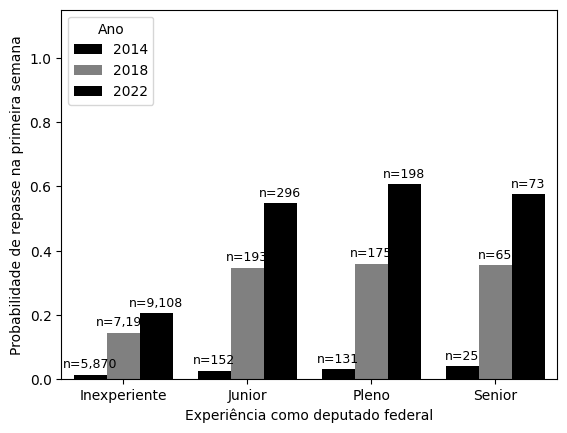

In [22]:
rrd_df_merge["repasse_semana1"] = (rrd_df_merge["dias_primeira_receita"] <= 7).astype(int)

# Criar categorias de experiência
rrd_df_merge["exp_deputado_federal"] = pd.cut(
    rrd_df_merge["n_eleicoes_deputado_federal"],
    bins=[-0.1, 0.9, 1.9, 3.9, 100],
    labels=["Inexperiente", "Junior", "Pleno", "Senior"]
)

# Calcular média e contagem por categoria e ano
df_plot = (
    rrd_df_merge
    .groupby(["exp_deputado_federal", "ano_eleicao"], observed=True)
    .agg(
        prob_repasse=("repasse_semana1", "mean"),
        n_obs=("repasse_semana1", "count")
    )
    .reset_index()
)

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(data=df_plot,
                 x="exp_deputado_federal",
                 y="prob_repasse",
                 hue="ano_eleicao",
                 palette=["black", "grey"])

# Adicionar rótulos com número de observações em cada barra
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        # Encontrar o n_obs correspondente
        x_pos = bar.get_x() + bar.get_width() / 2
        # Procurar no df_plot
        for idx, row in df_plot.iterrows():
            if abs(height - row['prob_repasse']) < 0.001:  # tolerância para comparação float
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.ylabel("Probabilidade de repasse na primeira semana")
plt.xlabel("Experiência como deputado federal")
plt.ylim(0, 1.15)
plt.legend(title="Ano", loc="upper left")

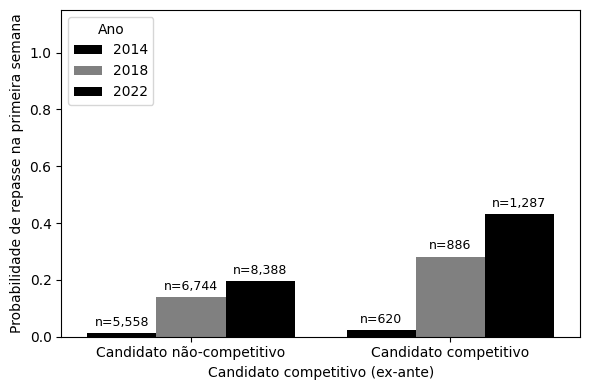

In [23]:

# ── Probabilidade de repasse na 1ª semana — candidato competitivo vs. não-competitivo ──
# candidato_competitivo já computado na rrd_df_merge

df_plot_cs = (
    rrd_df_merge.groupby(["candidato_competitivo", "ano_eleicao"], observed=True)
    .agg(
        prob_repasse=("repasse_semana1", "mean"),
        n_obs=("repasse_semana1", "count"),
    )
    .reset_index()
)
df_plot_cs["grupo_cs"] = df_plot_cs["candidato_competitivo"].map(
    {True: "Candidato competitivo", False: "Candidato não-competitivo"}
)

fig_bar, ax = plt.subplots(figsize=(6, 4))

ax = sns.barplot(
    data=df_plot_cs,
    x="grupo_cs",
    y="prob_repasse",
    hue="ano_eleicao",
    palette=["black", "grey"],
    ax=ax,
)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        for _, row in df_plot_cs.iterrows():
            if abs(height - row["prob_repasse"]) < 0.001:
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylabel("Probabilidade de repasse na primeira semana")
ax.set_xlabel("Candidato competitivo (ex-ante)")
ax.set_ylim(0, 1.15)
ax.legend(title="Ano", loc="upper left")
plt.tight_layout()
plt.show()


In [24]:
# ── Análise de fluxo acumulado de recursos por semana ────────────────────────
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1) Dados transacionais — todos os tipos de receita
df_rec = main().copy()

# 2) Sub-conjunto: apenas repasses partidários (FP / PJ_ROTEADO / FEFC)
df_rec_partido = df_rec[df_rec["fonte_tipo"].isin(FONTES_PARTIDO)].copy()

# 3) Dias e semana dentro da campanha
for _df in [df_rec, df_rec_partido]:
    _df["dias_campanha"] = _df.apply(
        lambda r: (r["dt_receita"] - JANELAS[r["ano_eleicao"]][0]).days, axis=1
    )
    _df["semana"] = (_df["dias_campanha"] // 7) + 1

max_semana = {ano: int(np.ceil(dur / 7)) for ano, dur in DURACAO.items()}

# 4) Vincular experiência como dep. federal
exp_cols = ["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato", "n_eleicoes_deputado_federal"]
_exp_lookup = rrd_df_merge[exp_cols].drop_duplicates()

df_rec = df_rec.merge(_exp_lookup, on=["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato"], how="left")
df_rec_partido = df_rec_partido.merge(_exp_lookup, on=["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato"], how="left")

for _df in [df_rec, df_rec_partido]:
    _df["n_eleicoes_deputado_federal"] = _df["n_eleicoes_deputado_federal"].fillna(0).astype(int)
    _df["exp_group"] = pd.cut(
        _df["n_eleicoes_deputado_federal"],
        bins=[-0.1, 0, 1, 100],
        labels=["Sem experiencia", "1 mandato", "2+ mandatos"],
    )


def calc_cumulative(df, group_cols):
    agg = (
        df.groupby(group_cols + ["semana"], observed=True)["vr_receita"]
        .sum().reset_index().sort_values(group_cols + ["semana"])
    )
    keys = agg[group_cols].drop_duplicates()
    expanded_rows = []
    for _, row in keys.iterrows():
        mask = pd.Series(True, index=agg.index)
        for col in group_cols:
            mask &= (agg[col] == row[col])
        ano = row["ano_eleicao"]
        semanas_completas = pd.DataFrame({"semana": range(1, max_semana[ano] + 1)})
        grupo_df = agg[mask][["semana", "vr_receita"]].merge(
            semanas_completas, on="semana", how="right"
        ).fillna(0)
        for col in group_cols:
            grupo_df[col] = row[col]
        expanded_rows.append(grupo_df)
    agg_full = pd.concat(expanded_rows, ignore_index=True).sort_values(group_cols + ["semana"])
    agg_full["cum_receita"] = agg_full.groupby(group_cols, observed=True)["vr_receita"].cumsum()
    totais = agg_full.groupby(group_cols, observed=True)["vr_receita"].transform("sum")
    agg_full["cum_prop"] = agg_full["cum_receita"] / totais
    return agg_full


# Análises de experiência: apenas recursos partidários
df_cum_overall = calc_cumulative(df_rec_partido, ["ano_eleicao"])
df_cum_exp     = calc_cumulative(df_rec_partido, ["ano_eleicao", "exp_group"])

print("Dados prontos.")
print(f"Semanas por ano: {max_semana}")
print(f"\nReceita total — TODOS os tipos (R$ milhões):")
print((df_rec.groupby("ano_eleicao")["vr_receita"].sum() / 1e6).round(1))
print(f"\nReceita total — apenas FP/PJ_ROTEADO/FEFC (R$ milhões):")
print((df_rec_partido.groupby("ano_eleicao")["vr_receita"].sum() / 1e6).round(1))
print(f"\nComposição 2014 por fonte_tipo (R$ milhões):")
print((df_rec[df_rec["ano_eleicao"]==2014].groupby("fonte_tipo")["vr_receita"].sum() / 1e6).sort_values(ascending=False).round(1))


Dados prontos.
Semanas por ano: {2014: 13, 2018: 8, 2022: 7}

Receita total — TODOS os tipos (R$ milhões):
ano_eleicao
2014    1035.4
2018    1298.1
2022    3171.7
Name: vr_receita, dtype: float64

Receita total — apenas FP/PJ_ROTEADO/FEFC (R$ milhões):
ano_eleicao
2014     405.8
2018    1026.8
2022    2815.0
Name: vr_receita, dtype: float64

Composição 2014 por fonte_tipo (R$ milhões):
fonte_tipo
PJ_ROTEADO     375.5
PJ_DIRETO      302.6
PF             129.7
OUTROS_CAND    102.2
PROPRIO         94.4
FP              30.3
OUTROS           0.8
Name: vr_receita, dtype: float64


In [25]:
cores  = {"Sem experiencia": "lightgrey", "1 mandato": "steelblue", "2+ mandatos": "black"}
tracas = {"Sem experiencia": "dot",       "1 mandato": "dash",       "2+ mandatos": "solid"}
grupos = ["Sem experiencia", "1 mandato", "2+ mandatos"]
anos   = [2018, 2022]
# ── Tabela-resumo: marcos acumulados por grupo de experiência e ano ───────────
rows = []
for ano in [2018, 2022]:
    for grupo in grupos:
        d = df_cum_exp[
            (df_cum_exp["ano_eleicao"] == ano) & (df_cum_exp["exp_group"] == grupo)
        ].sort_values("semana")

        total_milhoes = d["vr_receita"].sum() / 1e6

        def pct_ate_semana(s):
            linha = d[d["semana"] == s]
            return linha["cum_prop"].values[0] if len(linha) else np.nan

        # Semana mediana: primeira semana em que acumulado >= 50%
        mediana = d[d["cum_prop"] >= 0.5]["semana"].min()

        rows.append({
            "Ano": ano,
            "Grupo": grupo,
            "Total (R$ mi)": round(total_milhoes, 1),
            "% até S1": f"{pct_ate_semana(1):.1%}",
            "% até S2": f"{pct_ate_semana(2):.1%}",
            "% até S4": f"{pct_ate_semana(4):.1%}",
            "Semana mediana (50%)": int(mediana) if not pd.isna(mediana) else "—",
        })

df_tabela = pd.DataFrame(rows)
df_tabela


,Ano,Grupo,Total (R$ mi),% até S1,% até S2,% até S4,Semana mediana (50%)
0,2018,Sem experiencia,549.7,7.7%,40.4%,68.8%,3
1,2018,1 mandato,204.4,14.9%,64.5%,84.2%,2
2,2018,2+ mandatos,272.8,11.5%,63.5%,83.4%,2
3,2022,Sem experiencia,1866.3,12.9%,43.6%,78.4%,3
4,2022,1 mandato,472.9,23.4%,60.4%,88.8%,2
5,2022,2+ mandatos,475.8,27.8%,59.2%,87.2%,2


In [26]:

# ── Vantagem de experiência por tipo de partido (Competitivo vs. Menos Competitivo) ──
# Usa df_rec_partido (FP/PJ_ROTEADO/FEFC) — recursos sob controle do partido

cadeiras_nacionais = (
    rrd_df_merge[rrd_df_merge["eleito"] == 1]
    .groupby(["ano_eleicao", "sg_partido"])
    .size()
    .reset_index(name="n_cadeiras")
)
cadeiras_nacionais["tipo_partido"] = np.where(
    cadeiras_nacionais["n_cadeiras"] >= 20, "Competitivo", "Menos competitivo"
)

df_rec_tipo = df_rec_partido.merge(
    cadeiras_nacionais[["ano_eleicao", "sg_partido", "tipo_partido"]],
    on=["ano_eleicao", "sg_partido"],
    how="left",
)
df_rec_tipo["tipo_partido"] = df_rec_tipo["tipo_partido"].fillna("Menos competitivo")

df_cum_tipo = calc_cumulative(df_rec_tipo, ["ano_eleicao", "tipo_partido", "exp_group"])

tipos   = ["Competitivo", "Menos competitivo"]
anos    = [2018, 2022]
cores   = {"Sem experiencia": "lightgrey", "1 mandato": "steelblue", "2+ mandatos": "black"}
tracas  = {"Sem experiencia": "dot",       "1 mandato": "dash",       "2+ mandatos": "solid"}
grupos  = ["Sem experiencia", "1 mandato", "2+ mandatos"]

fig3 = make_subplots(
    rows=2, cols=2,
    shared_yaxes=True,
    shared_xaxes=True,
    row_titles=tipos,
    column_titles=[str(a) for a in anos],
    vertical_spacing=0.10,
    horizontal_spacing=0.06,
)

for row_idx, tipo in enumerate(tipos, start=1):
    for col_idx, ano in enumerate(anos, start=1):
        d_painel = df_cum_tipo[
            (df_cum_tipo["ano_eleicao"] == ano) &
            (df_cum_tipo["tipo_partido"] == tipo)
        ]
        for grupo in grupos:
            d = d_painel[d_painel["exp_group"] == grupo].sort_values("semana")
            if d.empty:
                continue
            fig3.add_trace(
                go.Scatter(
                    x=d["semana"],
                    y=d["cum_prop"],
                    mode="lines+markers",
                    name=grupo,
                    showlegend=(row_idx == 1 and col_idx == 1),
                    line=dict(color=cores[grupo], dash=tracas[grupo], width=2),
                    marker=dict(size=5),
                ),
                row=row_idx, col=col_idx,
            )

fig3.update_layout(
    title_text="Vantagem de experiência por tipo de partido — proporção acumulada por semana",
    legend=dict(title="Experiência (Dep. Federal)", orientation="h", y=-0.10, x=0.5, xanchor="center"),
    height=600,
    width=860,
    template="plotly_white",
)
fig3.update_xaxes(title_text="Semana", dtick=1, row=2)
fig3.update_yaxes(tickformat=".0%", range=[0, 1.05])
fig3.update_yaxes(title_text="Proporção acumulada", col=1)

fig3.show(config={"staticPlot": True})


In [27]:
# ── Proporção acumulada por semana — competitivo vs. não-competitivo ─────────
# Layout 2×3:
#   Linha 1 → 2014 Total (todos os recursos) | 2014 FP | 2014 PJ→Partido
#   Linha 2 → 2018 FEFC+FP                   | 2022 FEFC+FP | (vazio)

cs_cols = ["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]
_cs_lookup = rrd_df_merge[cs_cols].drop_duplicates()

def _add_grupo_cs(df_src):
    out = df_src.merge(_cs_lookup, on=["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato"], how="left")
    out["candidato_competitivo"] = out["candidato_competitivo"].fillna(False)
    out["grupo_cs"] = out["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    return out

# df_rec_cs: todos os tipos (2014 Total mostrará ~R$1,1B)
df_rec_cs = _add_grupo_cs(df_rec)
# df_rec_cs_partido: apenas FP/PJ_ROTEADO/FEFC (painéis 2018/2022)
df_rec_cs_partido = _add_grupo_cs(df_rec_partido)

cores_cs  = {"Candidato competitivo": "black",  "Candidato não-competitivo": "lightgrey"}
tracas_cs = {"Candidato competitivo": "solid",   "Candidato não-competitivo": "dot"}
grupos_cs = ["Candidato competitivo", "Candidato não-competitivo"]

d14 = df_rec_cs[df_rec_cs["ano_eleicao"] == 2014]
PAINEIS_PROP = [
    ("2014 — Total (todos os recursos)",  d14),
    ("2014 — Fundo Partidário",           d14[d14["fonte_tipo"] == "FP"]),
    ("2014 — PJ → Partido → Cand.",       d14[d14["fonte_tipo"] == "PJ_ROTEADO"]),
    ("2018 — FEFC+FP",                    df_rec_cs_partido[df_rec_cs_partido["ano_eleicao"] == 2018]),
    ("2022 — FEFC+FP",                    df_rec_cs_partido[df_rec_cs_partido["ano_eleicao"] == 2022]),
]

specs_2x3 = [
    [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    [{"type": "xy"}, {"type": "xy"}, None],
]
pos_prop = {i: (1 + i // 3, (i % 3) + 1) for i in range(len(PAINEIS_PROP))}

fig_cs = make_subplots(
    rows=2, cols=3,
    subplot_titles=[p[0] for p in PAINEIS_PROP],
    specs=specs_2x3,
    vertical_spacing=0.18,
    horizontal_spacing=0.06,
)

for i, (titulo, df_fonte) in enumerate(PAINEIS_PROP):
    row, col = pos_prop[i]
    df_cum = calc_cumulative(df_fonte, ["ano_eleicao", "grupo_cs"])
    for grupo in grupos_cs:
        d = df_cum[df_cum["grupo_cs"] == grupo].sort_values("semana")
        if d.empty:
            continue
        fig_cs.add_trace(
            go.Scatter(
                x=d["semana"], y=d["cum_prop"],
                mode="lines+markers", name=grupo,
                showlegend=(i == 0),
                line=dict(color=cores_cs[grupo], dash=tracas_cs[grupo], width=2),
                marker=dict(size=6),
            ),
            row=row, col=col,
        )

fig_cs.update_layout(
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.10, yanchor="top"),
    height=720, width=1200, template="plotly_white",
    margin=dict(t=80, b=50),
)
fig_cs.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_cs.update_yaxes(tickformat=".0%", range=[0, 1.05])
fig_cs.update_yaxes(title_text="Proporção acumulada", col=1)

fig_cs.show(config={"staticPlot": True})
fig_cs.write_image("figs/cap3_cumulative_proportion_cs.png", scale=2)


In [28]:
# Valor absoluto acumulado (R$ milhões) — mesmo layout 2×3
# Usa PAINEIS_PROP, specs_2x3, pos_prop definidos na célula anterior

fig_cs_abs = make_subplots(
    rows=2, cols=3,
    subplot_titles=[p[0] for p in PAINEIS_PROP],
    specs=specs_2x3,
    vertical_spacing=0.18,
    horizontal_spacing=0.12,
)

for i, (titulo, df_fonte) in enumerate(PAINEIS_PROP):
    row, col = pos_prop[i]
    df_cum = calc_cumulative(df_fonte, ["ano_eleicao", "grupo_cs"])
    for grupo in grupos_cs:
        d = df_cum[df_cum["grupo_cs"] == grupo].sort_values("semana")
        if d.empty:
            continue
        fig_cs_abs.add_trace(
            go.Scatter(
                x=d["semana"], y=d["cum_receita"] / 1e6,
                mode="lines+markers", name=grupo,
                showlegend=(i == 0),
                line=dict(color=cores_cs[grupo], dash=tracas_cs[grupo], width=2),
                marker=dict(size=6),
            ),
            row=row, col=col,
        )

fig_cs_abs.update_layout(
    legend=dict(
                orientation="h", x=0.5, xanchor="center", y=1.10, yanchor="top"),
    height=720, width=1200, template="plotly_white",
    margin=dict(t=80, b=50),
)
fig_cs_abs.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_cs_abs.update_yaxes(title_text="R$ acumulado (milhões)", col=1)

fig_cs_abs.write_image("figs/cap3_cumulative_abs_cs.png", scale=2)
fig_cs_abs.show(config={"staticPlot": True})


In [29]:
# ── Composição do financiamento por fonte — fluxo cumulativo absoluto ────────
# Cada linha = um tipo de recurso; 3 painéis (2014 | 2018 | 2022)
# Revela como a proibição de PJ (2015) e a criação do FEFC (2017) recompuseram
# o financiamento de campanhas.

CORES_FONTE = {
    "PJ_DIRETO":              "#e15759",
    "PJ_ROTEADO":             "#f28e2b",
    "FP":                     "#4e79a7",
    "FEFC":                   "#4e79a7",
    "PF":                     "#76b7b2",
    "PROPRIO":                "#59a14f",
    "OUTROS_CAND":            "#b07aa1",
    "FINANCIAMENTO_COLETIVO": "#edc948",
    "OUTROS":                 "#bab0ac",
}
DASHES_FONTE = {
    "PJ_DIRETO": "solid",  "PJ_ROTEADO": "solid", "FP": "dash",
    "FEFC":      "solid",  "PF":         "dot",   "PROPRIO": "dashdot",
    "OUTROS_CAND": "dot",  "FINANCIAMENTO_COLETIVO": "longdash", "OUTROS": "dot",
}
# Ordem de plotagem por ano (maior → menor volume esperado)
FONTES_ORDEM = {
    2014: ["PJ_DIRETO", "PJ_ROTEADO", "PF", "PROPRIO", "OUTROS_CAND", "FP", "OUTROS"],
    2018: ["FEFC", "PF", "PROPRIO", "OUTROS_CAND", "FP", "FINANCIAMENTO_COLETIVO", "OUTROS"],
    2022: ["FEFC", "PF", "PROPRIO", "OUTROS_CAND", "FP", "FINANCIAMENTO_COLETIVO", "OUTROS"],
}

fig_fontes = make_subplots(
    rows=1, cols=3,
    subplot_titles=["2014 (pré-FEFC)", "2018", "2022"],
    shared_yaxes=False,
    horizontal_spacing=0.08,
)

seen_legend = set()
for col_idx, ano in enumerate([2014, 2018, 2022], start=1):
    df_ano = df_rec[df_rec["ano_eleicao"] == ano].copy()
    df_cum_f = calc_cumulative(df_ano, ["ano_eleicao", "fonte_tipo"])

    fontes_com_valor = (
        df_ano.groupby("fonte_tipo")["vr_receita"].sum()
        .loc[lambda s: s > 0].index.tolist()
    )
    ordem = [f for f in FONTES_ORDEM[ano] if f in fontes_com_valor]

    for fonte in ordem:
        d = df_cum_f[df_cum_f["fonte_tipo"] == fonte].sort_values("semana")
        if d.empty:
            continue
        total_m = d["vr_receita"].sum() / 1e6
        label = f"{fonte} (R${total_m:.0f}M)"
        show = fonte not in seen_legend
        seen_legend.add(fonte)
        fig_fontes.add_trace(
            go.Scatter(
                x=d["semana"], y=d["cum_receita"] / 1e6,
                mode="lines+markers", name=label,
                legendgroup=fonte,
                showlegend=show,
                line=dict(color=CORES_FONTE.get(fonte, "#aaaaaa"),
                          dash=DASHES_FONTE.get(fonte, "solid"), width=2.5),
                marker=dict(size=5),
            ),
            row=1, col=col_idx,
        )

fig_fontes.update_layout(
    title_text="Composição do financiamento de campanha por fonte — Dep. Federal<br>"
               "<sup>PJ_DIRETO e PJ_ROTEADO extintos após STF/2015; FEFC criado em 2017</sup>",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.22, yanchor="top",
                font=dict(size=11)),
    height=500, width=1200, template="plotly_white",
    margin=dict(t=70, b=120),
)
fig_fontes.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_fontes.update_yaxes(title_text="R$ acumulado (milhões)", col=1)

fig_fontes.write_image("figs/cap4_cumulative_2014_fontes.png", scale=2)
fig_fontes.show(config={"staticPlot": True})
